**Fine-Tuning BERT for Text Classification** 

Table of contents
     
1.   Environment setup
2.   Data Preparation
3.   Tokenization
4.   Model Selection and Training
5.   Testing and Predicting

**1. Environment setup**

In our example, it is not essential, but generally for complex tasks the training procedure would benefit from the availability of GPU. In Colab, we can enable GPU by selecting 
> Runtime -> Change runtime type

First, we install the Hugging Face⁴ transformers library as follows:

In [1]:
!pip install transformers

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 57.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 106.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.1/200.1 kB 26.1 MB/s eta 0:00:00


and, We import the needed dependencies:

In [12]:
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np

from tabulate import tabulate
from tqdm import trange
import random

import warnings
warnings.filterwarnings(action='once')

**2. Data Preparation**
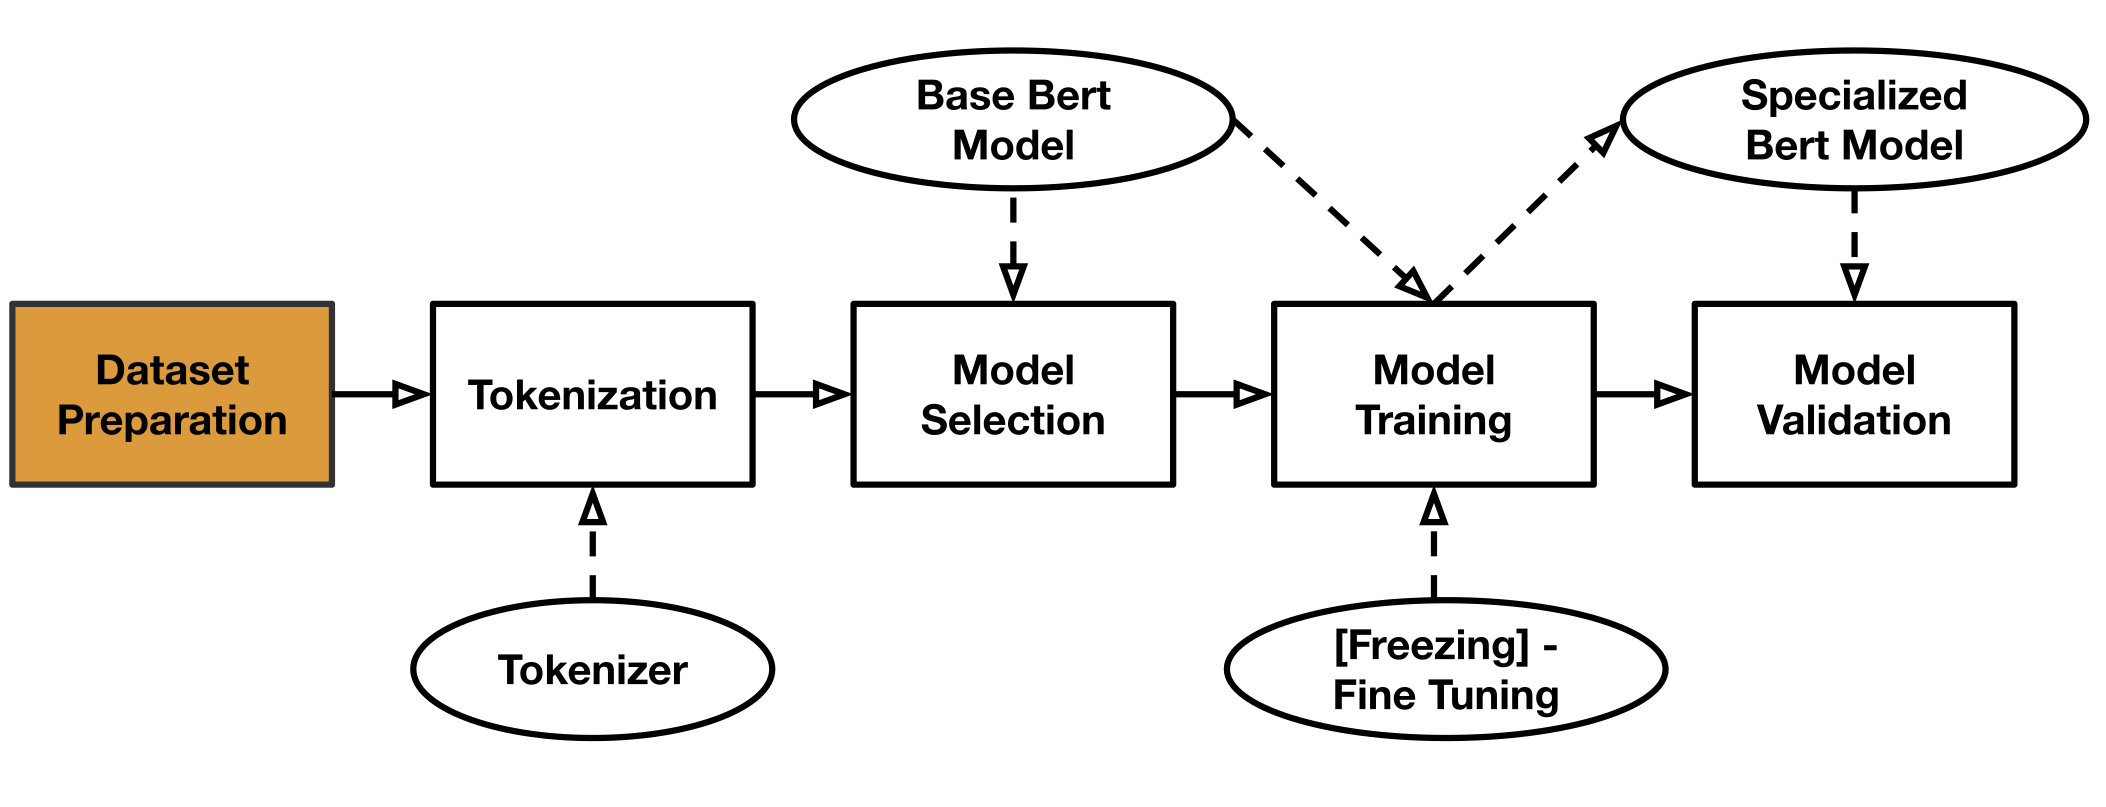

We use the public SMS Spam Collection Data Set⁵ from the UCI Machine Learning Repository⁶. The data consists of a text file with a set of SMS messages labeled as either spam or ham. From the Colab notebook:



*   Download the dataset as a zip folder:



In [13]:
!wget 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'

--2023-04-19 08:11:48--  https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 203415 (199K) [application/x-httpd-php]
Saving to: ‘smsspamcollection.zip.2’

smsspamcollection.z 100%[===================>] 198.65K   391KB/s    in 0.5s    

2023-04-19 08:11:50 (391 KB/s) - ‘smsspamcollection.zip.2’ saved [203415/203415]





*   Unpack the folder:




In [14]:
!unzip -o smsspamcollection.zip

Archive:  smsspamcollection.zip
  inflating: SMSSpamCollection       
  inflating: readme                  


* Inspect the first rows of the data file:



In [15]:
!head -10 SMSSpamCollection

ham	Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
ham	Ok lar... Joking wif u oni...
spam	Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
ham	U dun say so early hor... U c already then say...
ham	Nah I don't think he goes to usf, he lives around here though
spam	FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv
ham	Even my brother is not like to speak with me. They treat me like aids patent.
ham	As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune
spam	WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.
spam	H

* For each line, the label is followed by a tab space and the raw text message. We choose to process the file to get a pandas.DataFrame object, as it is a common starting point in Data Science experiments:

In [16]:
file_path = '/content/SMSSpamCollection'
df = pd.DataFrame({'label':int(), 'text':str()}, index = [])
with open(file_path) as f:
  for line in f.readlines():
    split = line.split('\t')
    df = df.append({'label': 1 if split[0] == 'spam' else 0,
                    'text': split[1]},
                    ignore_index = True)
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...\n
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


* We extract text and label values:

In [17]:
text = df.text.values
labels = df.label.values

Divide the dataset in Train Set, Validation Set, and Test Set

Initially, we divide the entire dataset using the classic 70-30 rule, reserving 70% of the total for the **training set** and 30% for validation operations.

Specifically, since the tutorial involves 2 different phases of checking the model outputs, one during the training phase and another a posteriori, we are also going to divide the remaining 30% into:

- 1/3 of the remaining set (33%), which we will use as the **validation set** during the training phase; 
- 2/3 of the remaining set (66%), which we will use as the a posteriori **test set** of the training. 

In [33]:
test_ratio = 0.3

val_ratio = 0.33

# Recommended batch size: 16, 32. See: https://arxiv.org/pdf/1810.04805.pdf
batch_size = 16

# Indices of the train set and temp set(validation + test sets) splits stratified by labels
train_text, temp_text, train_labels, temp_labels = train_test_split(
    text,
    labels,
    test_size = test_ratio,
    shuffle = True,
    stratify = labels)

# We divide then temp_idx in test_idx (test set) and val_idx ( validation set)
test_text, val_text, test_labels, val_labels = train_test_split(
    temp_text,
    temp_labels,
    test_size = val_ratio,
    shuffle = True,
    stratify = temp_labels)

**3. Tokenization**
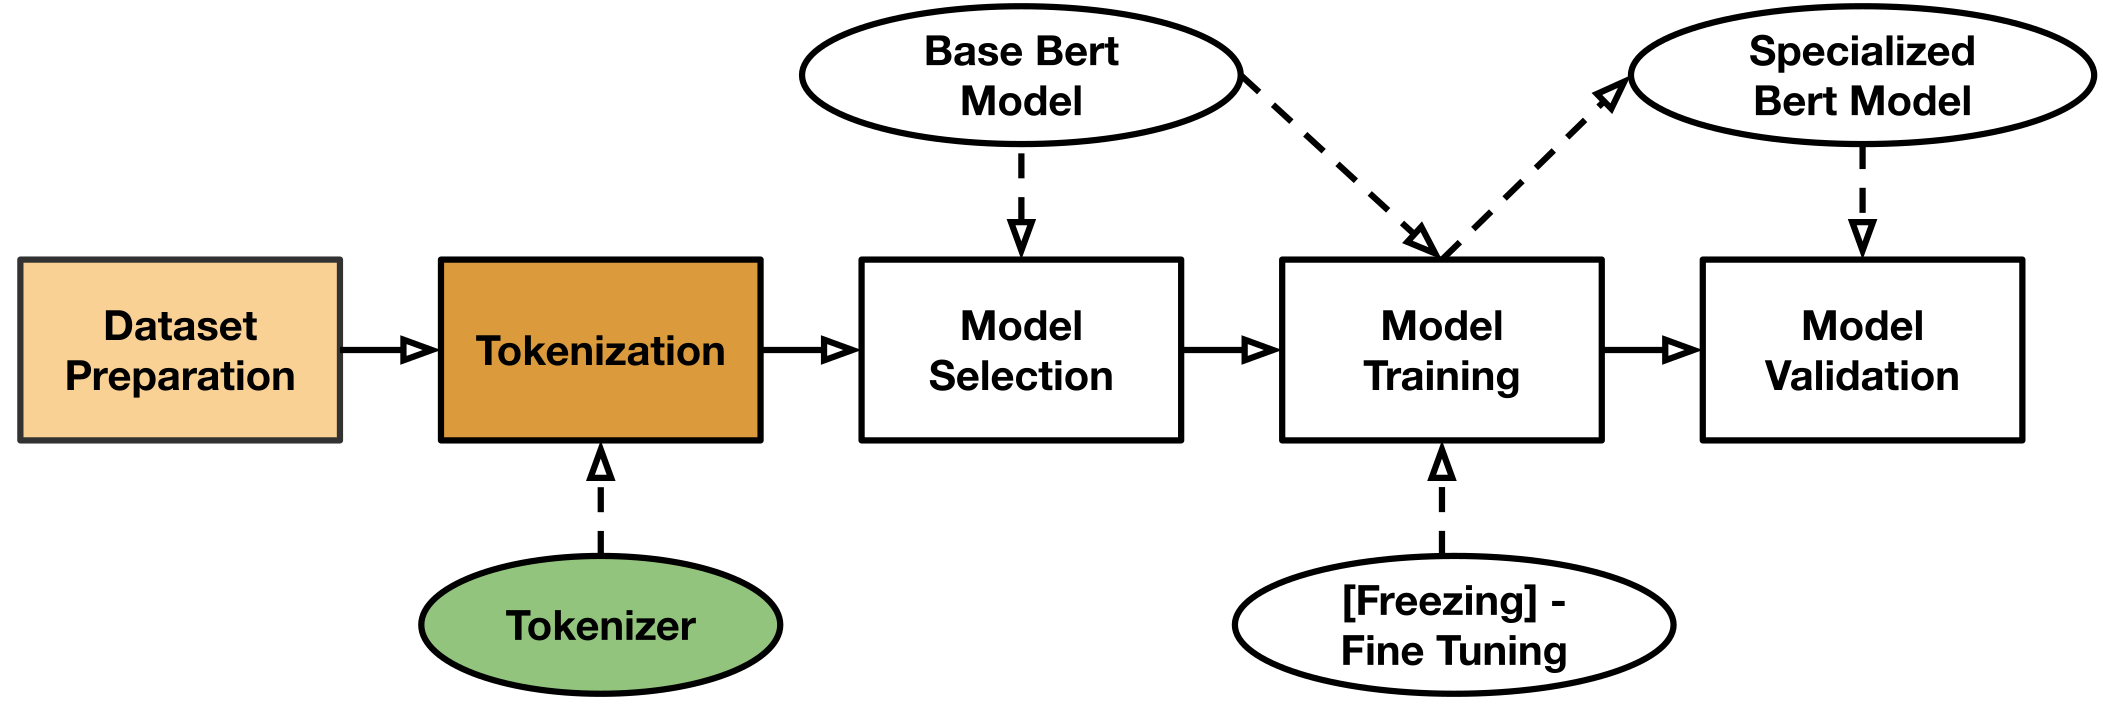
We need to preprocess the text source before feeding it to BERT. To do so, we download the BertTokenizer:

In [34]:
tokenizer = BertTokenizer.from_pretrained(
    'bert-base-uncased',
    do_lower_case = True
)

Let us observe how the tokenizer can split a random sentence into word-level tokens and map them to their respective IDs in the BERT vocabulary:

In [35]:
def print_rand_sentence():
  '''Displays the tokens and respective IDs of a random text sample'''
  index = random.randint(0, len(text)-1)
  table = np.array([tokenizer.tokenize(text[index]), 
                    tokenizer.convert_tokens_to_ids(tokenizer.tokenize(text[index]))]).T
  print(tabulate(table,
                 headers = ['Tokens', 'Token IDs'],
                 tablefmt = 'fancy_grid'))

print_rand_sentence()

╒══════════╤═════════════╕
│ Tokens   │   Token IDs │
╞══════════╪═════════════╡
│ i        │        1045 │
├──────────┼─────────────┤
│ haven    │        4033 │
├──────────┼─────────────┤
│ ##t      │        2102 │
├──────────┼─────────────┤
│ lei      │       26947 │
├──────────┼─────────────┤
│ .        │        1012 │
├──────────┼─────────────┤
│ .        │        1012 │
├──────────┼─────────────┤
│ next     │        2279 │
├──────────┼─────────────┤
│ mon      │       12256 │
├──────────┼─────────────┤
│ can      │        2064 │
├──────────┼─────────────┤
│ ?        │        1029 │
╘══════════╧═════════════╛


BERT requires the following preprocessing steps:



1.   Add special tokens:
      
> [CLS]: at the beginning of each sentence (ID 101)


> [SEP]: at the end of each sentence (ID 102)


       


2.   Make sentences of the same length: This is achieved by padding, i.e. adding values of convenience to shorter sequences to match the desired length. Longer sequences are truncated.

> The padding ([PAD]) tokens have ID 0.

> The maximum sequence length allowed is of 512 tokens¹.



3.   Create an attention mask: List of 0/1 indicating whether the model should consider the tokens or not when learning their contextual representation.



> We expect [PAD] tokens to have value 0.

The process can be represented as follows:

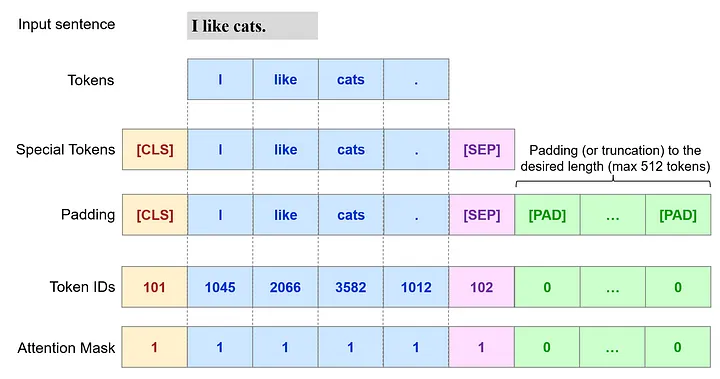

We can perform all the needed steps by using the tokenizer.encode_plus⁷ method. When called, it returns a:
  
> transformers.tokenizationtokenization-utils_base.BatchEncoding

object with the following fields:



> input_ids: list of token IDs.


> token_type_ids: list of token type IDs.


> attention_mask: list of 0/1 

indicating which tokens should be considered by the model (return_attention_mask = True).

As we choose max_length = 32, longer sentences will be truncated, while shorter sentences will be populated with [PAD] tokens (id: 0) until they reach the desired length.

Considering those elements, we can perform the tokenization on all instance of the Training, Validation and Test sets 

In [36]:
'''Tokenize each set splitted''' 


def preprocessing(input_text, tokenizer):
  '''
  Returns <class transformers.tokenization_utils_base.BatchEncoding> with the following fields:
    - input_ids: list of token ids
    - token_type_ids: list of token type ids
    - attention_mask: list of indices (0,1) specifying which tokens should considered by the model (return_attention_mask = True).
  '''
  return tokenizer.encode_plus(
                        input_text,
                        add_special_tokens = True,
                        max_length = 32,
                        pad_to_max_length = True,
                        return_attention_mask = True,
                        return_tensors = 'pt'
                   )

def preprocessing_batch(data_set):
    token_id = []
    attention_masks = []
    for sample in data_set:
      encoding_dict = preprocessing(sample, tokenizer)
      token_id.append(encoding_dict['input_ids']) 
      attention_masks.append(encoding_dict['attention_mask'])
    token_id = torch.cat(token_id, dim = 0)
    attention_masks = torch.cat(attention_masks, dim = 0)
    return token_id,attention_masks

train_token_id,train_attention_masks = preprocessing_batch(train_text)
test_token_id,test_attention_masks = preprocessing_batch(test_text)
val_token_id,val_attention_masks = preprocessing_batch(val_text)

train_labels = torch.tensor(train_labels)
test_labels = torch.tensor(test_labels)
val_labels = torch.tensor(val_labels)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


We can observe the token IDs for a text sample and recognize the presence of the special tokens [CLS] and [SEP], as well as the padding [PAD] up to the desired max_length:

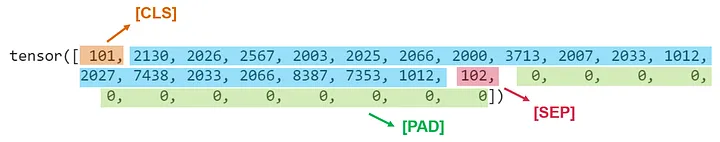

We can also verify the output of tokenizer.encode_plus by inspecting tokens, their IDs and the attention mask for random text samples as follows:

In [37]:
def print_rand_sentence_encoding(text, token_id,attention_masks):
  '''Displays tokens, token IDs and attention mask of a random text sample'''
  index = random.randint(0, len(text) - 1)
  tokens = tokenizer.tokenize(tokenizer.decode(token_id[index]))
  token_ids = [i.numpy() for i in token_id[index]]
  attention = [i.numpy() for i in attention_masks[index]]

  table = np.array([tokens, token_ids, attention]).T
  print(tabulate(table, 
                 headers = ['Tokens', 'Token IDs', 'Attention Mask'],
                 tablefmt = 'fancy_grid'))

#For instance selectiong a random instance of the training set  
print_rand_sentence_encoding(test_text, train_token_id,train_attention_masks)

╒══════════╤═════════════╤══════════════════╕
│ Tokens   │   Token IDs │   Attention Mask │
╞══════════╪═════════════╪══════════════════╡
│ [CLS]    │         101 │                1 │
├──────────┼─────────────┼──────────────────┤
│ i        │        1045 │                1 │
├──────────┼─────────────┼──────────────────┤
│ think    │        2228 │                1 │
├──────────┼─────────────┼──────────────────┤
│ your     │        2115 │                1 │
├──────────┼─────────────┼──────────────────┤
│ mentor   │       10779 │                1 │
├──────────┼─────────────┼──────────────────┤
│ is       │        2003 │                1 │
├──────────┼─────────────┼──────────────────┤
│ ,        │        1010 │                1 │
├──────────┼─────────────┼──────────────────┤
│ but      │        2021 │                1 │
├──────────┼─────────────┼──────────────────┤
│ not      │        2025 │                1 │
├──────────┼─────────────┼──────────────────┤
│ 100      │        2531 │        

To properly train and validate a transformer such as a standard neural network, it is necessary to define exact portions of data (the data batches) to be passed to the network at set intervals. To properly automate this process, you can use the Data Loader, which, with its intuitive syntax, provides an iterable on the given data set.

More information on DataLoader can be found here:

*   https://pytorch.org/tutorials/beginner/basics/data_tutorial.html#preparing-your-data-for-training-with-dataloaders
*   https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader




In [38]:

# Recommended batch size: 16, 32. See: https://arxiv.org/pdf/1810.04805.pdf
batch_size = 16

# Train and validation sets
train_set = TensorDataset(train_token_id, 
                          train_attention_masks, 
                          train_labels)

val_set = TensorDataset(val_token_id, 
                        val_attention_masks, 
                        val_labels)

test_set = TensorDataset(test_token_id, 
                        test_attention_masks, 
                        test_labels)

# Prepare DataLoader
train_dataloader = DataLoader(
            train_set,
            sampler = RandomSampler(train_set),
            batch_size = batch_size
        )

validation_dataloader = DataLoader(
            val_set,
            sampler = SequentialSampler(val_set),
            batch_size = batch_size
        )


test_dataloader = DataLoader(
            test_set,
            sampler = SequentialSampler(test_set),
            batch_size = batch_size
        )

# **4. Model Selection and Training**

It is time for the fine-tuning task:


*   Select hyperparameters based on the recommendations from the BERT paper (): Devlin, Jacob; Chang, Ming-Wei; Lee, Kenton; Toutanova, Kristina, “BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding”, 2018, arXiv:1810.04805v2

The optimal hyperparameter values are task-specific, but we found the following range of possible values to work well across all tasks: 

> - Batch size: 16, 32
- Learning rate (Adam): 5e-5, 3e-5, 2e-5
- Number of epochs: 2, 3, 4

* Define some functions to assess validation metrics (accuracy, precision, recall and specificity) during the training process:

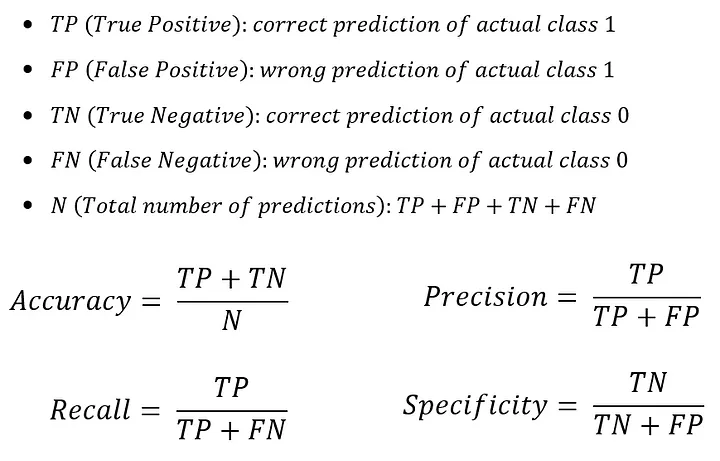



In [39]:
def b_tp(preds, labels):
  '''Returns True Positives (TP): count of correct predictions of actual class 1'''
  return sum([preds == labels and preds == 1 for preds, labels in zip(preds, labels)])

def b_fp(preds, labels):
  '''Returns False Positives (FP): count of wrong predictions of actual class 1'''
  return sum([preds != labels and preds == 1 for preds, labels in zip(preds, labels)])

def b_tn(preds, labels):
  '''Returns True Negatives (TN): count of correct predictions of actual class 0'''
  return sum([preds == labels and preds == 0 for preds, labels in zip(preds, labels)])

def b_fn(preds, labels):
  '''Returns False Negatives (FN): count of wrong predictions of actual class 0'''
  return sum([preds != labels and preds == 0 for preds, labels in zip(preds, labels)])

def b_metrics(preds, labels):
  '''
  Returns the following metrics:
    - accuracy    = (TP + TN) / N
    - precision   = TP / (TP + FP)
    - recall      = TP / (TP + FN)
    - specificity = TN / (TN + FP)
  '''
  preds = np.argmax(preds, axis = 1).flatten()
  labels = labels.flatten()
  tp = b_tp(preds, labels)
  tn = b_tn(preds, labels)
  fp = b_fp(preds, labels)
  fn = b_fn(preds, labels)
  b_accuracy = (tp + tn) / len(labels)
  b_precision = tp / (tp + fp) if (tp + fp) > 0 else 'nan'
  b_recall = tp / (tp + fn) if (tp + fn) > 0 else 'nan'
  b_specificity = tn / (tn + fp) if (tn + fp) > 0 else 'nan'
  return b_accuracy, b_precision, b_recall, b_specificity

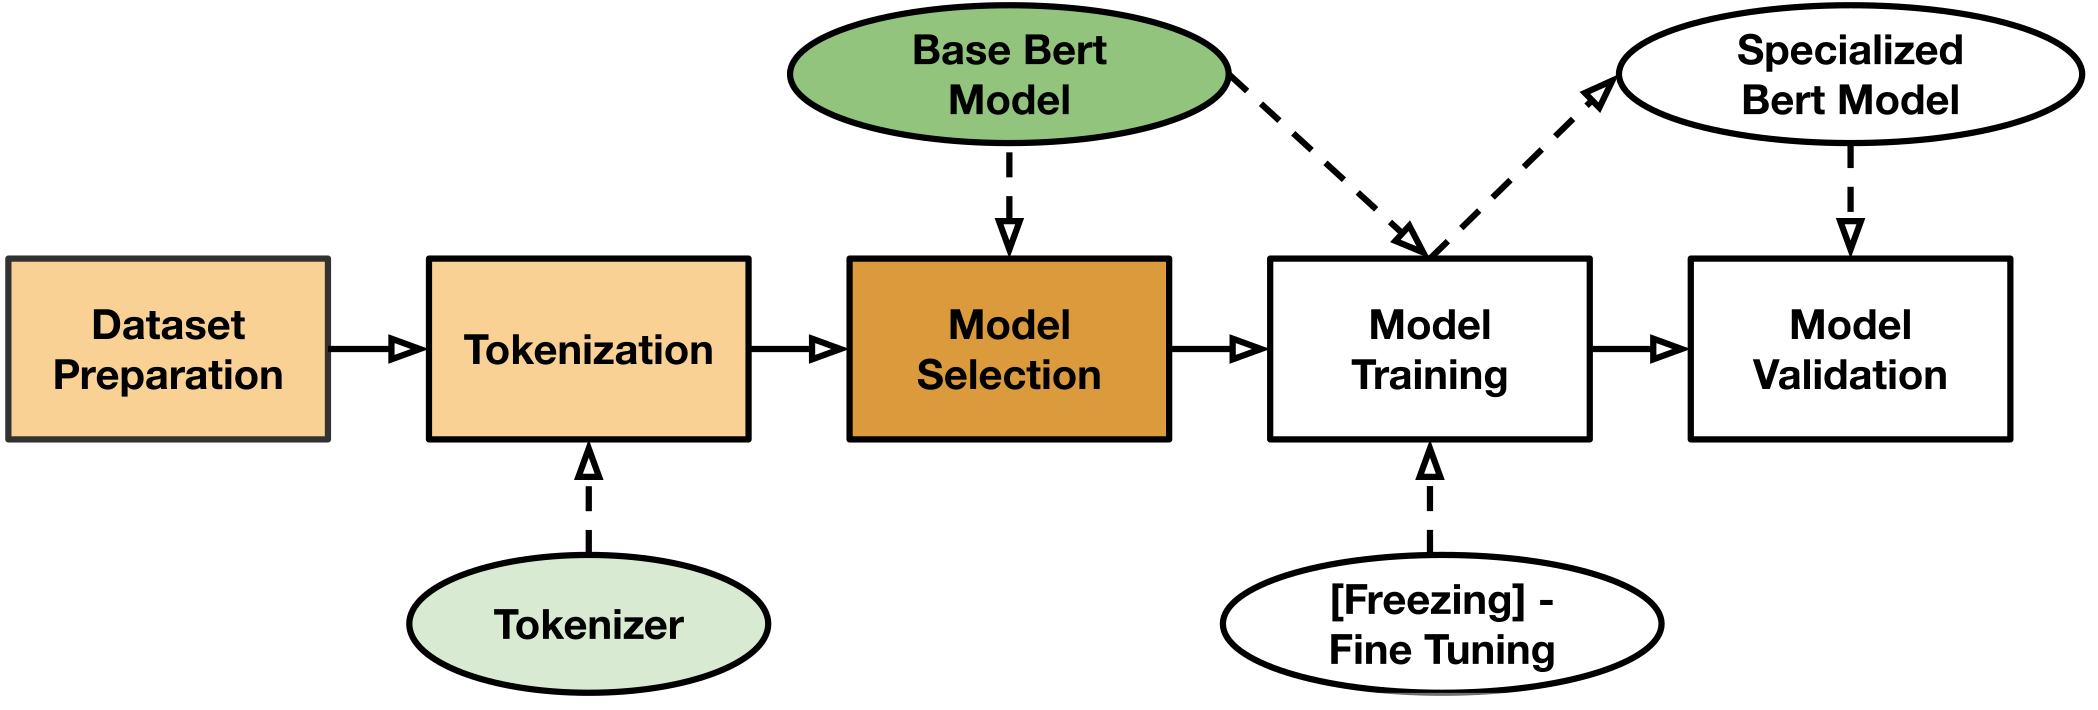
* Download transformers.BertForSequenceClassification¹¹, which is a BERT model with a linear layer for sentence classification (or regression) on top of the pooled output:

In [40]:
# Load the BertForSequenceClassification model
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels = 2,
    output_attentions = False,
    output_hidden_states = False,
)

# Recommended learning rates (Adam): 5e-5, 3e-5, 2e-5. See: https://arxiv.org/pdf/1810.04805.pdf
optimizer = torch.optim.AdamW(model.parameters(), 
                              lr = 5e-5,
                              eps = 1e-08
                              )

# Run on GPU
model.cuda()

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForSequenceClassification: ['cls.seq_relationship.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

Note: it is preferable to run this notebook in the presence of GPU. In order to execute it on CPU, we should comment model.cuda() in the above snippet to avoid a runtime error.

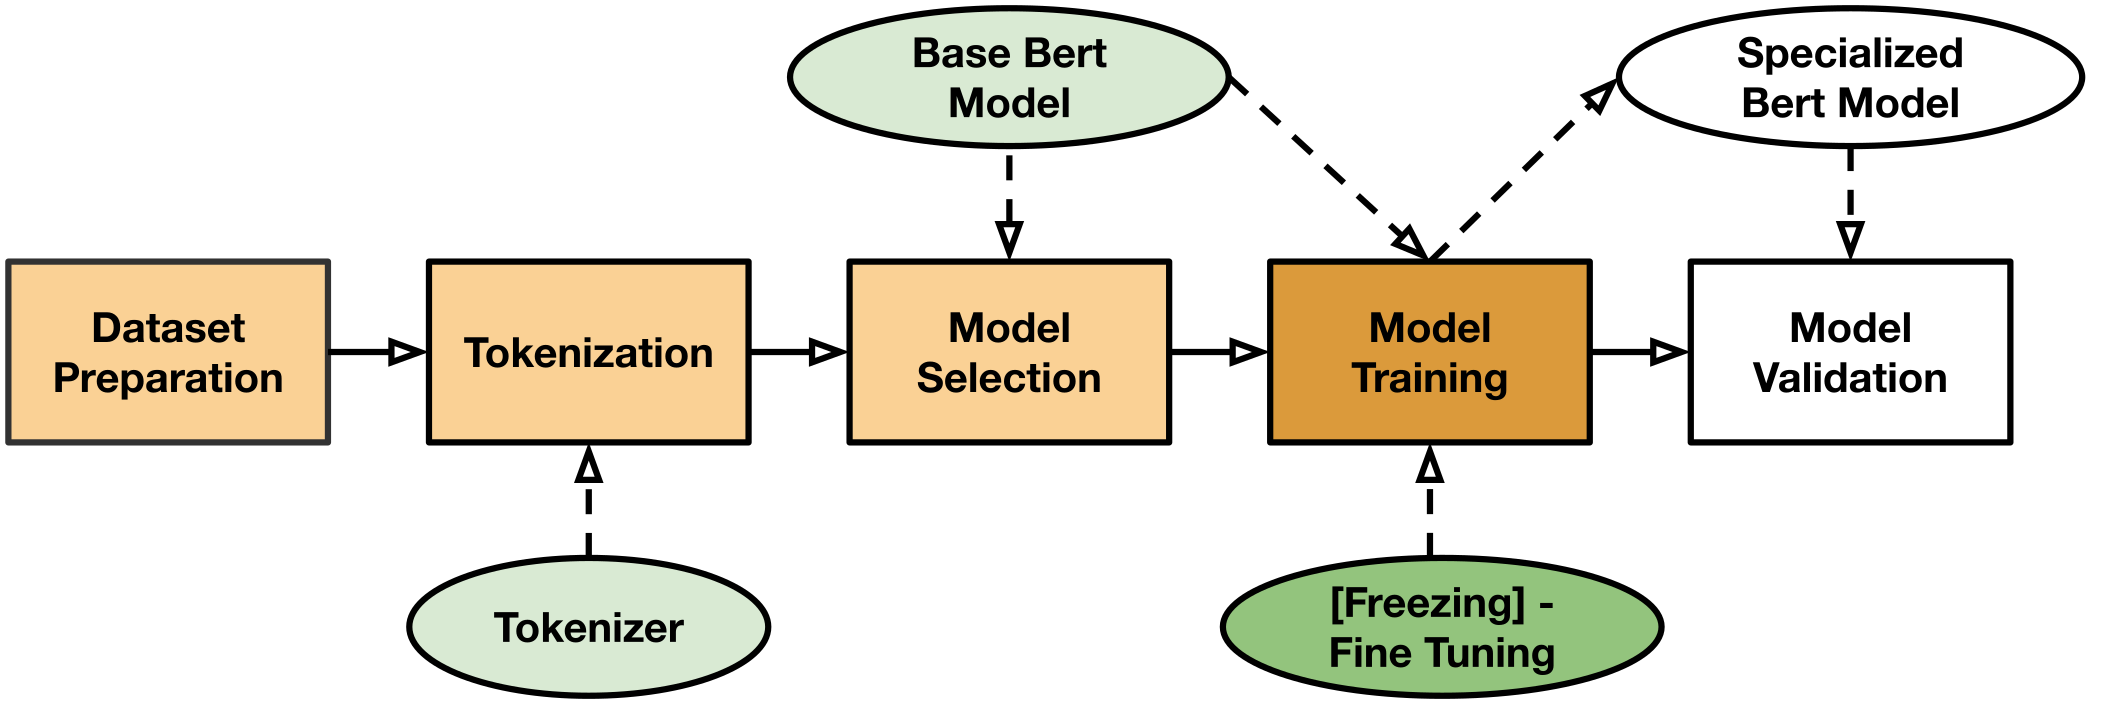
* Perform the training procedure:

In [41]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#Full Freezing 
# for param in model.bert.parameters():
#    param.requires_grad = False

#Addictional freezing example
#https://raphaelb.org/posts/freezing-bert/


# Recommended number of epochs: 2, 3, 4. See: https://arxiv.org/pdf/1810.04805.pdf
epochs = 2

for _ in trange(epochs, desc = 'Epoch'):
    
    # ========== Training ==========
    
    # Set model to training mode
    model.train()
    
    # Tracking variables
    tr_loss = 0
    nb_tr_examples, nb_tr_steps = 0, 0

    for step, batch in enumerate(train_dataloader):
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_input_mask, b_labels = batch
        #reset gradient value for the new epoch
        optimizer.zero_grad()
        # Forward pass
        train_output = model(b_input_ids, 
                             token_type_ids = None, 
                             attention_mask = b_input_mask, 
                             labels = b_labels)
        # Backward pass
        train_output.loss.backward()
        optimizer.step()
        # Update tracking variables
        tr_loss += train_output.loss.item()
        nb_tr_examples += b_input_ids.size(0)
        nb_tr_steps += 1

    # ========== Validation ==========

    # Set model to evaluation mode
    model.eval()

    # Tracking variables 
    val_accuracy = []
    val_precision = []
    val_recall = []
    val_specificity = []

    for batch in validation_dataloader:
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_input_mask, b_labels = batch
        with torch.no_grad():
          # Forward pass
          eval_output = model(b_input_ids, 
                              token_type_ids = None, 
                              attention_mask = b_input_mask)
        logits = eval_output.logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()
        # Calculate validation metrics
        b_accuracy, b_precision, b_recall, b_specificity = b_metrics(logits, label_ids)
        val_accuracy.append(b_accuracy)
        # Update precision only when (tp + fp) !=0; ignore nan
        if b_precision != 'nan': val_precision.append(b_precision)
        # Update recall only when (tp + fn) !=0; ignore nan
        if b_recall != 'nan': val_recall.append(b_recall)
        # Update specificity only when (tn + fp) !=0; ignore nan
        if b_specificity != 'nan': val_specificity.append(b_specificity)

    print('\n\t - Train loss: {:.4f}'.format(tr_loss / nb_tr_steps))
    print('\t - Validation Accuracy: {:.4f}'.format(sum(val_accuracy)/len(val_accuracy)))
    print('\t - Validation Precision: {:.4f}'.format(sum(val_precision)/len(val_precision)) if len(val_precision)>0 else '\t - Validation Precision: NaN')
    print('\t - Validation Recall: {:.4f}'.format(sum(val_recall)/len(val_recall)) if len(val_recall)>0 else '\t - Validation Recall: NaN')
    print('\t - Validation Specificity: {:.4f}\n'.format(sum(val_specificity)/len(val_specificity)) if len(val_specificity)>0 else '\t - Validation Specificity: NaN')

# save the trained model to a file
PATH = './bert.pth'
torch.save(model, PATH)

Epoch:  50%|█████     | 1/2 [00:31<00:31, 31.07s/it]


	 - Train loss: 0.0913
	 - Validation Accuracy: 0.9893
	 - Validation Precision: 0.9740
	 - Validation Recall: 0.9343
	 - Validation Specificity: 0.9959



Epoch: 100%|██████████| 2/2 [01:00<00:00, 30.35s/it]


	 - Train loss: 0.0203
	 - Validation Accuracy: 0.9875
	 - Validation Precision: 0.9844
	 - Validation Recall: 0.9116
	 - Validation Specificity: 0.9981



# **5. Testing and Predicting**

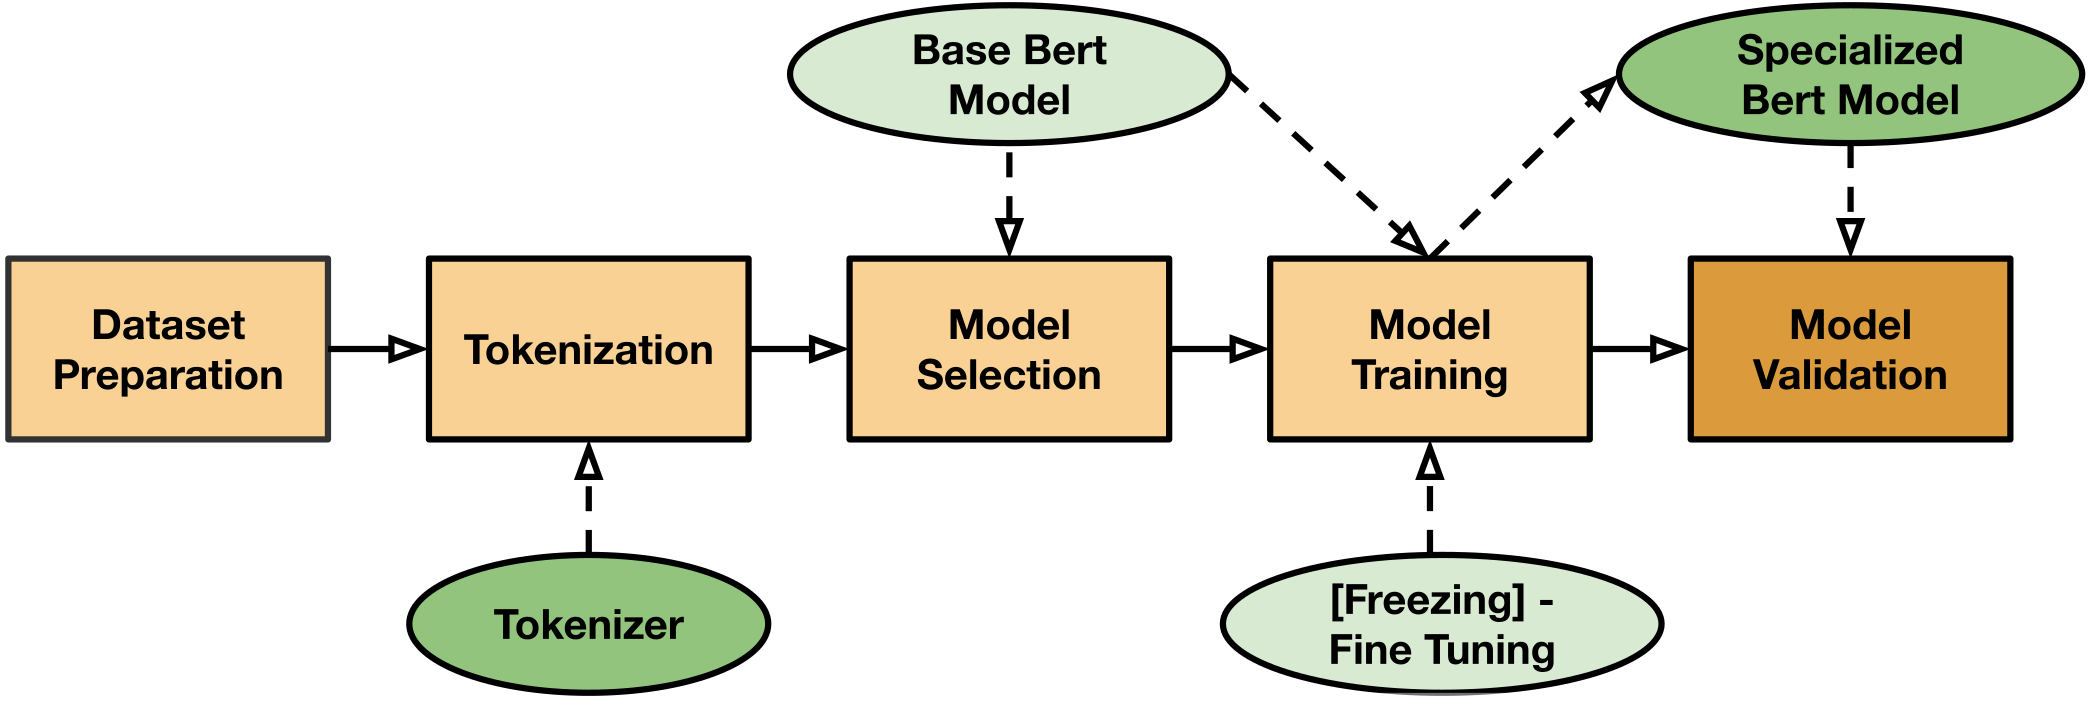

After a training procedure, it is a good practice to assess the model’s performances on a test set. For the purpose of this example, we will compute again the validation metrics on the test set, we previously defined:

In [42]:
# load the model saved
PATH = './bert.pth'
model = torch.load(PATH)

# Tracking variables 
test_accuracy = []
test_precision = []
test_recall = []
test_specificity = []

for batch in test_dataloader:
    batch = tuple(t.to(device) for t in batch)
    b_input_ids, b_input_mask, b_labels = batch

    eval_output = model(b_input_ids, 
                        token_type_ids = None, 
                        attention_mask = b_input_mask)
    logits = eval_output.logits.detach().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()
    # Calculate validation metrics
    b_accuracy, b_precision, b_recall, b_specificity = b_metrics(logits, label_ids)
    test_accuracy.append(b_accuracy)
    # Update precision only when (tp + fp) !=0; ignore nan
    if b_precision != 'nan': test_precision.append(b_precision)
    # Update recall only when (tp + fn) !=0; ignore nan
    if b_recall != 'nan': test_recall.append(b_recall)
    # Update specificity only when (tn + fp) !=0; ignore nan
    if b_specificity != 'nan': test_specificity.append(b_specificity)

print('\t - Test Accuracy: {:.4f}'.format(sum(test_accuracy)/len(test_accuracy)))
print('\t - Test Precision: {:.4f}'.format(sum(test_precision)/len(test_precision)) if len(test_precision)>0 else '\t - Test Precision: NaN')
print('\t - Test Recall: {:.4f}'.format(sum(test_recall)/len(test_recall)) if len(test_recall)>0 else '\t - Test Recall: NaN')
print('\t - Test Specificity: {:.4f}\n'.format(sum(test_specificity)/len(test_specificity)) if len(test_specificity)>0 else '\t - Test Specificity: NaN')

	 - Test Accuracy: 0.9893
	 - Test Precision: 0.9413
	 - Test Recall: 0.9633
	 - Test Specificity: 0.9919



And finally to visualize how the specialized network works, we can observe a specific example on a specific sentence 

In [43]:
new_sentence = 'WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.'
# load the model saved
PATH = './bert.pth'
model = torch.load(PATH)
# We need Token IDs and Attention Mask for inference on the new sentence
predict_ids = []
predict_attention_mask = []

# Apply the tokenizer
encoding = preprocessing(new_sentence, tokenizer)

# Extract IDs and Attention Mask
predict_ids.append(encoding['input_ids'])
predict_attention_mask.append(encoding['attention_mask'])
predict_ids = torch.cat(predict_ids, dim = 0)
predict_attention_mask = torch.cat(predict_attention_mask, dim = 0)

# Forward pass, calculate logit predictions
with torch.no_grad():
  output = model(predict_ids.to(device), token_type_ids = None, attention_mask = predict_attention_mask.to(device))

prediction = 'Spam' if np.argmax(output.logits.cpu().numpy()).flatten().item() == 1 else 'Ham'

print('Input Sentence: ', new_sentence)
print('Predicted Class: ', prediction)

Input Sentence:  WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.
Predicted Class:  Spam


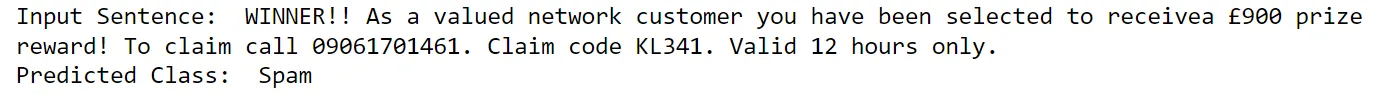

Credits: https://towardsdatascience.com/fine-tuning-bert-for-text-classification-54e7df642894#ec34